K-means clustering using Python on IBM watsonx.ai
https://developer.ibm.com/tutorials/awb-k-means-clustering-in-python/

Step 2. Generate a data set

In [2]:
import pandas as pd 
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
X, y = make_blobs(n_samples=5000, n_features=5, centers=5, cluster_std = 0.5, random_state=42)

In [4]:
# Convert to DataFrame
df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])

#add a final column explaining which blob each row should be in
df['label'] = y

#save df as csv
#df.to_csv('df.csv')

#to open a csv, use read_csv()

In [5]:
df.rename(columns={
     'feature_0': 'distance_center',
     'feature_1': 'num_rooms',
     'feature_2': 'property_size',
     'feature_3': 'age',
     'feature_4': 'utility_cost',
}, inplace=True)

df.head() 

,distance_center,num_rooms,property_size,age,utility_cost,label
0,-7.125259,-8.744736,7.188210,1.819037,4.104709,1
1,-7.217549,-8.930194,6.774529,0.740323,4.112526,1
2,-9.278846,8.544481,6.165782,-5.859933,-5.758941,2
3,-9.278868,9.960691,6.785733,-5.763617,-6.156320,2
4,-6.450608,-3.684872,-0.295743,-0.239884,-4.289207,3


Step 3. Perform exploratory data analysis

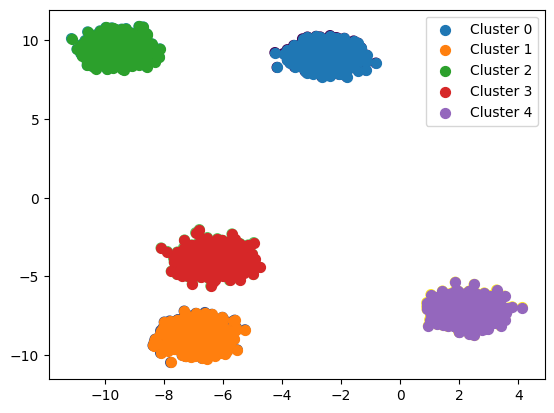

In [6]:
# Visualize the blobs
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')

# Annotate each point with its label
unique_labels = set(y)
for label in unique_labels:
    plt.scatter(X[y == label][:, 0], X[y == label][:, 1], s=50, label=f'Cluster {label}')

plt.legend(loc='upper right')

plt.show()

In [7]:
print(df.dtypes)

distance_center    float64
num_rooms          float64
property_size      float64
age                float64
utility_cost       float64
label                int32
dtype: object


In [8]:
df.isnull().sum()

distance_center    0
num_rooms          0
property_size      0
age                0
utility_cost       0
label              0
dtype: int64

Step 4. Choose K

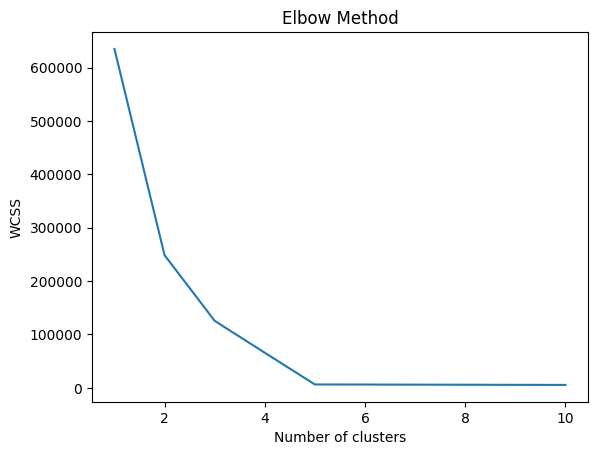

In [9]:
# Use the elbow method to find a good number of clusters using WCSS (within-cluster sums of squares)
wcss = []

# Let's check for up to 10 clusters
for i in range(1, 11):
     kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
     kmeans.fit(df)
     wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [12]:
#Run K-Means:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)

#fit model
kmeans.fit(df)

#add predicted labels to df
df['predicted_labels'] = kmeans.predict(df)

Step 5. Interpret K-means clustering

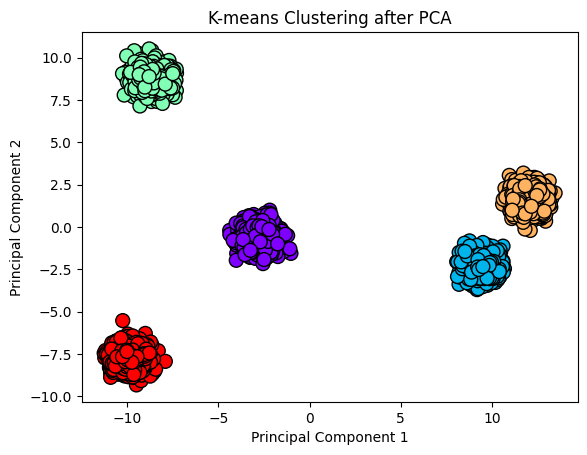

In [15]:
# PCA reduction
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df.drop(columns=['predicted_labels']))

# Visualize the clusters in the reduced dimensionality
predicted_labels = df['predicted_labels']

plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=predicted_labels, cmap='rainbow', edgecolors='k', s=100)
plt.title("K-means Clustering after PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

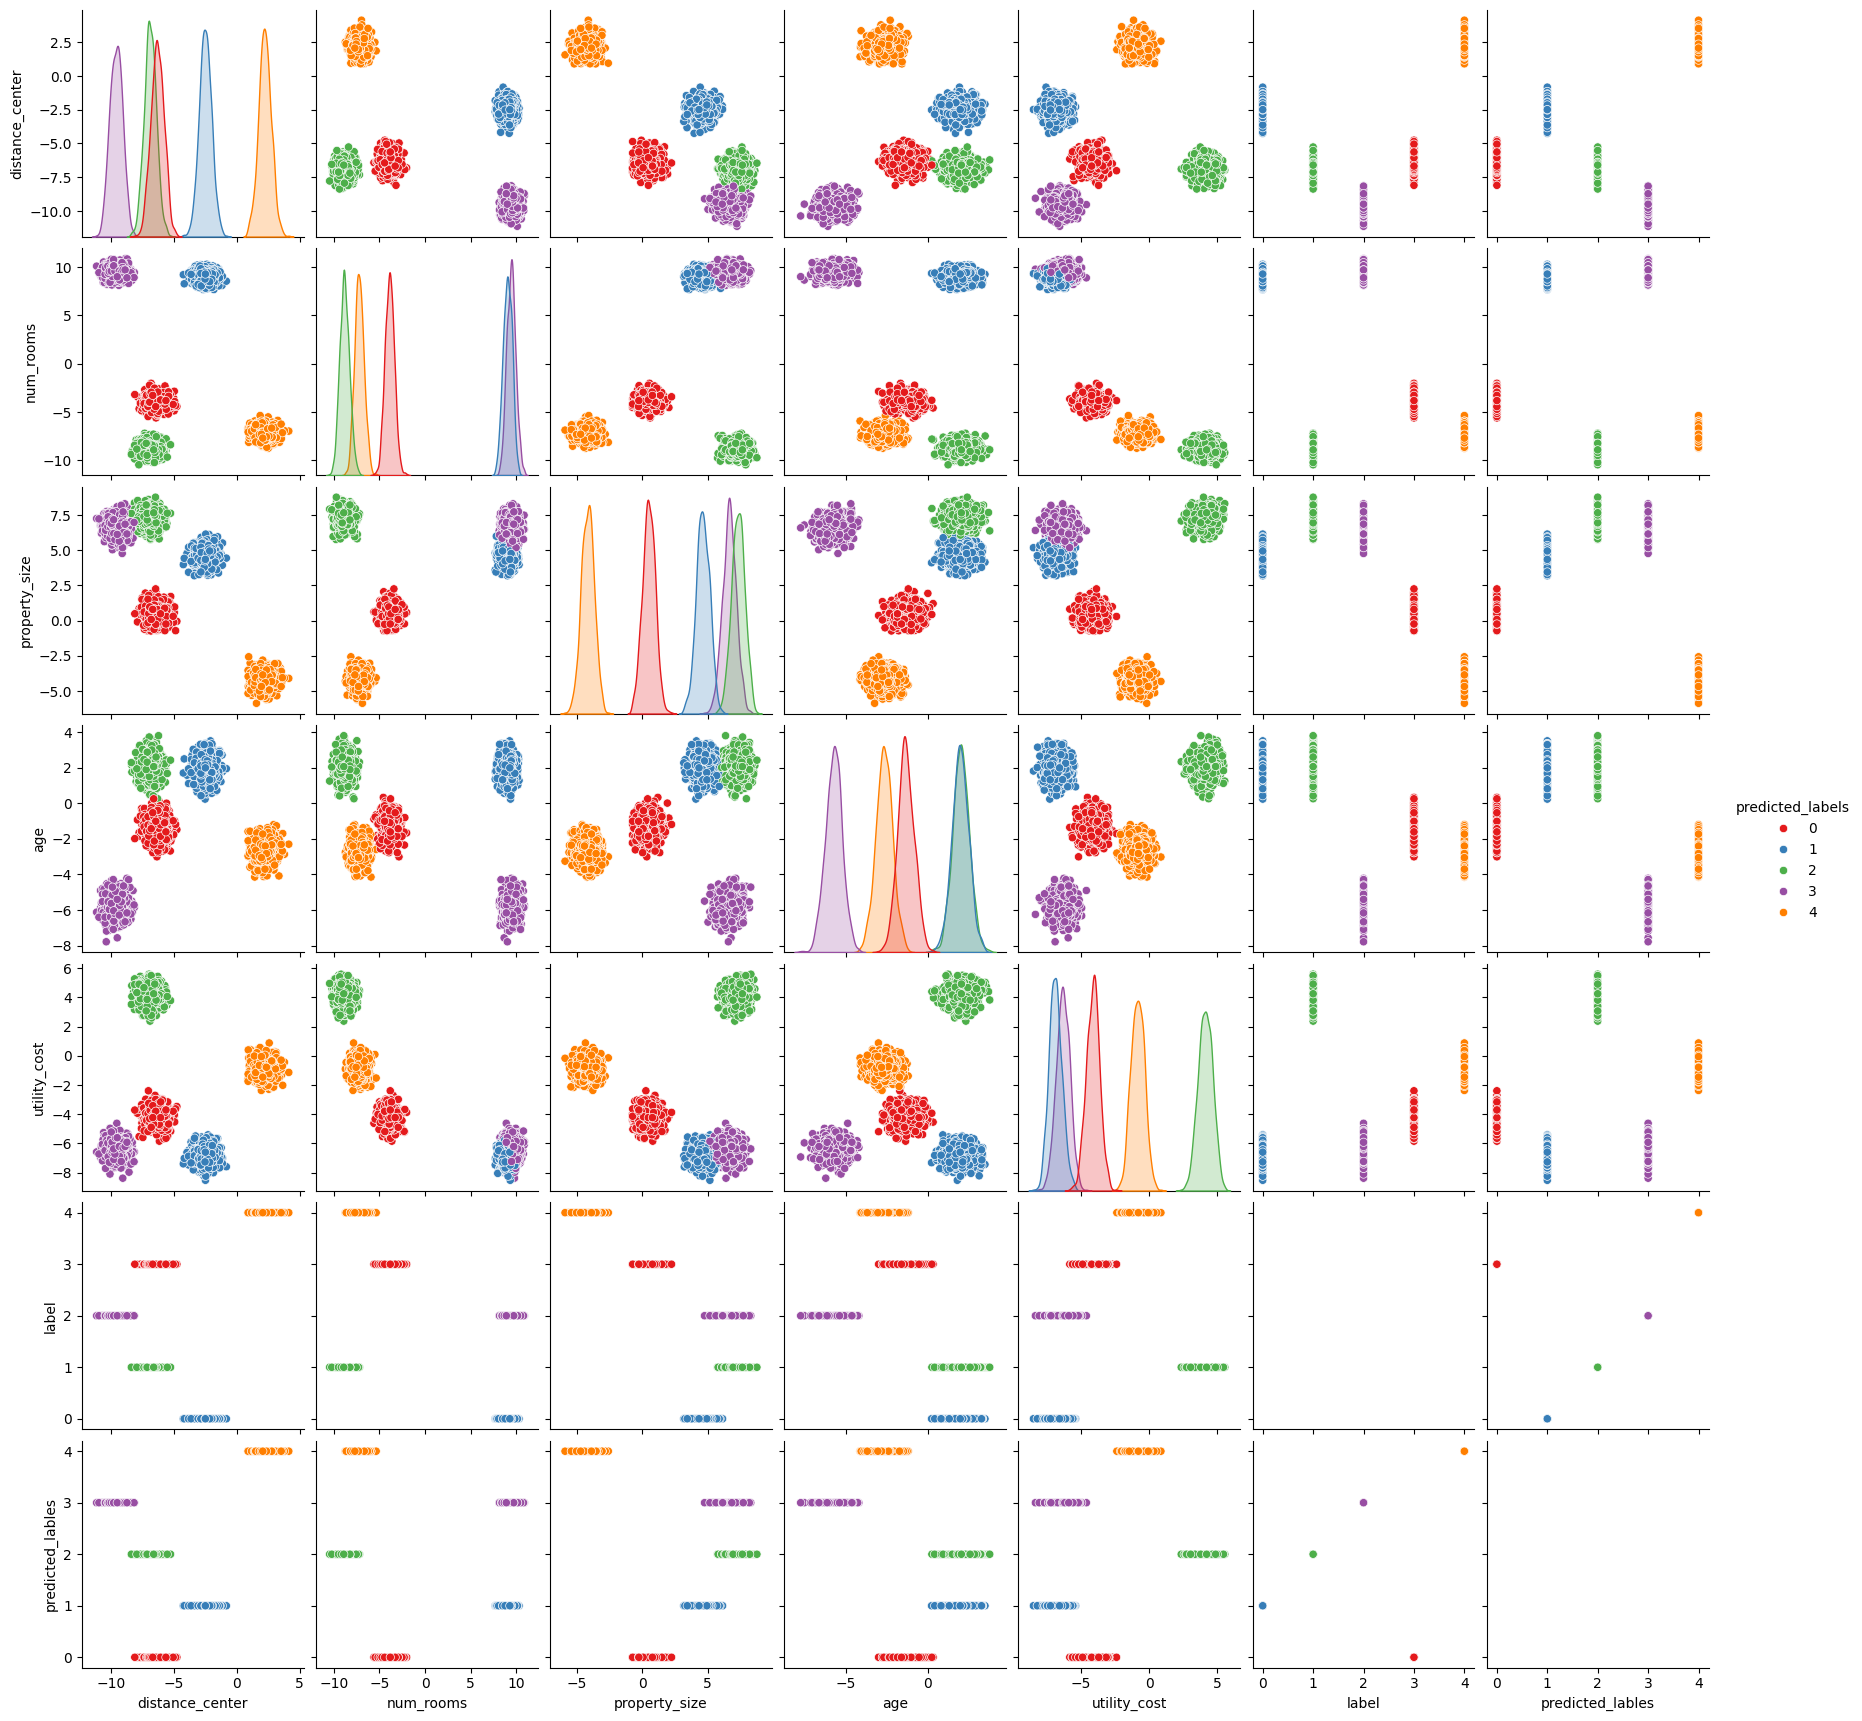

In [16]:
# Assuming `df` is your DataFrame and `predicted_labels` is the column with cluster assignments
sns.pairplot(df, hue='predicted_labels', palette='Set1')
plt.show()